# Bootstrapped Datasets and Null Models


In [16]:
import os
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from promdis.processing import get_sequence_arrays_and_counts, gene_seq_to_array
from promdis.core import compute_expression_shift_by_mutation
from promdis.core import compute_expression_shift_by_pairwise_mutation
from promdis.helpers import get_segments
from promdis.pl import plot_data_2d

In [17]:
OUTDIR = "../out/nullmodels"

os.makedirs(OUTDIR, exist_ok=True)

SEED = 42
rng = np.random.default_rng(seed=SEED)

Begin by loading data.

In [18]:
FPATH = "../data/expression_data/ykgE_dataset_combined.csv"


In [19]:
df = pd.read_csv(FPATH)
df['barcode'] = df['seq'].str.slice(160,)
df['promoter'] = df['seq'].str.slice(0, 160)
df

,ct,ct_0,ct_1,seq,barcode,promoter
0,1.0,1.0,0.0,ACAATTTCACCATAAAATGTCGGCGTTGCCGAAAGAAATAAAATGA...,GAGAGCCTCGCGTATCCCTC,ACAATTTCACCATAAAATGTCGGCGTTGCCGAAAGAAATAAAATGA...
1,1.0,1.0,0.0,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...,GGATCCATGGTCATTCGGTG,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...
2,1.0,1.0,0.0,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...,TATTACGGTACGAGATTGCT,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...
3,2.0,2.0,0.0,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...,AACTCTCACTCTGCTGTACG,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...
4,2.0,2.0,0.0,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...,TACCCGTGTTCGTAACCCCT,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...
...,...,...,...,...,...,...
2585,1.0,1.0,0.0,TTGTTTTCGCCATAAATTGTGAGCGATGCCGTAAGAAACAAAATTA...,CGCATACGGTAGAAGCGGAA,TTGTTTTCGCCATAAATTGTGAGCGATGCCGTAAGAAACAAAATTA...
2586,2.0,1.0,1.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,CGTCCTTTACGTACTATGGG,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...
2587,1.0,1.0,0.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,CACGTCAGCGGCCCTCTTAC,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...
2588,1.0,1.0,0.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,GTATCCGTGCGACCATCCAA,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...


Compute expression level as the ratio of mRNA counts to the total number of counts (mRNA and DNA combined).
The function below converts the data into a numpy array format, and converts string sequences into integer sequences.

In [20]:
seqs, counts_dna, counts_rna = get_sequence_arrays_and_counts(
    df, key_promoter='promoter', key_rna='ct_1', key_dna='ct_0'
)

expression = counts_rna / (counts_dna + counts_rna)

Load the gene of interest's wildtype sequence, and convert it to a numpy array form as well.

In [21]:
# Load wildtype data

GENE = 'ykgE'

WT_GENES_FPATH = "../data/wtsequences.csv"

wildtype_genes_df = pd.read_csv(WT_GENES_FPATH)

WT_GENE_SEQUENCES = {
    g: wildtype_genes_df.loc[wildtype_genes_df['name'] == g,'geneseq'].values[0]
    for g in wildtype_genes_df['name'].unique()
}

GENE_WT_SEQ = WT_GENE_SEQUENCES[GENE]

nbases = len(GENE_WT_SEQ)
print(f"{GENE} wildtype sequence (length {nbases}):\n", GENE_WT_SEQ)

wt_seq = gene_seq_to_array(GENE_WT_SEQ)

ykgE wildtype sequence (length 160):
 TCGATTTCCCCATAAAATGTGAGCGATGCCGAAAGAAATAAAATTAGTTATTGCATTTGACGTTTGGATGAAAGATTATCATTTGTCATACAAATGAGGGGTGGTATGTTGCTAGCCAATTAAAAAAGAACGCCATATTTATTGATGATTGATCCCCCGG


## Bootstrapping

In [22]:
def generate_bootstrapped_data(
        seqs, expression, wt_seq, 
        rng=None, 
        seed=None,
):
    """Generate random wildtype mutants."""
    if rng is None:
        rng = np.random.default_rng(seed=seed)
    idxs = rng.choice(len(seqs), size=len(seqs), replace=True)
    boot_seqs = seqs[idxs,:]
    boot_expression = expression[idxs]
    return boot_seqs, boot_expression

In [23]:
SEGMENT_SIZE = 1
ALPHA = 0.05

In [24]:
# mutation_profile = [(1,0), (0,1)]
mutation_profile = [(1,)]

xi_data, _ = compute_expression_shift_by_mutation(
    seqs, expression, wt_seq, 
    segment_size=SEGMENT_SIZE,
    profile_groups=mutation_profile,
)

In [25]:
N_BOOT = 1000

# mutation_profile = [(1,0), (0,1)]
mutation_profile = [(1,)]

xis_boot = np.zeros([N_BOOT, *xi_data.shape])

for i in tqdm.trange(N_BOOT):
    boot_seqs, boot_expression = generate_bootstrapped_data(
        seqs, expression, wt_seq, rng, 
    )

    xi, _ = compute_expression_shift_by_mutation(
        boot_seqs, boot_expression, wt_seq, 
        segment_size=SEGMENT_SIZE,
        profile_groups=mutation_profile,
    )
    xis_boot[i] = xi
   

  0%|          | 0/1000 [00:00<?, ?it/s]

In [26]:
# Compute bootstrapped confidence intervals

xi_boot_ci_lower = np.percentile(xis_boot, 100*ALPHA/2, axis=0)
xi_boot_ci_upper = np.percentile(xis_boot, 100*(1-ALPHA/2), axis=0)

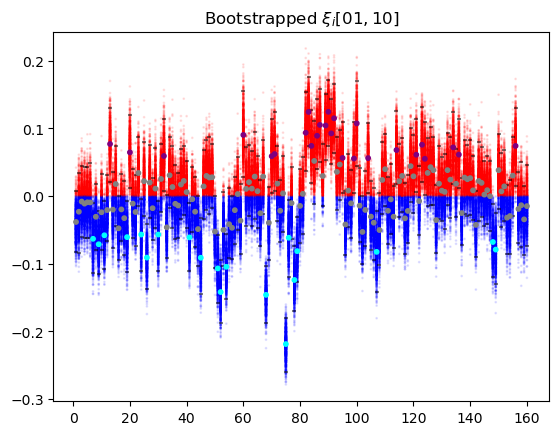

In [27]:
fig, ax = plt.subplots(1, 1)

xs = np.arange(1, len(xi_data) + 1)

for i in range(N_BOOT):
    xi = xis_boot[i]
    colors = ['b' if v < 0 else 'r' for v in xi]
    ax.scatter(xs, xi, color=colors, s=1, alpha=0.1)

ax.scatter(xs, xi_boot_ci_lower, color='k', alpha=0.5, s=5, marker='_')
ax.scatter(xs, xi_boot_ci_upper, color='k', alpha=0.5, s=5, marker='_')

conf_screen = xi_boot_ci_lower * xi_boot_ci_upper > 0

colors = []
for i in range(len(conf_screen)):
    if conf_screen[i]:
        v = xi_data[i]
        colors.append('cyan' if v < 0 else 'purple')
    else:
        colors.append('grey')

ax.scatter(xs, xi_data, color=colors, alpha=1, s=10)

ax.set_title("Bootstrapped $\\xi_i[01,10]$");

plt.savefig(f"{OUTDIR}/bootstrapped_xi_1d.pdf")

Let us also use bootstrapped data to explore the pairwise segment analysis.

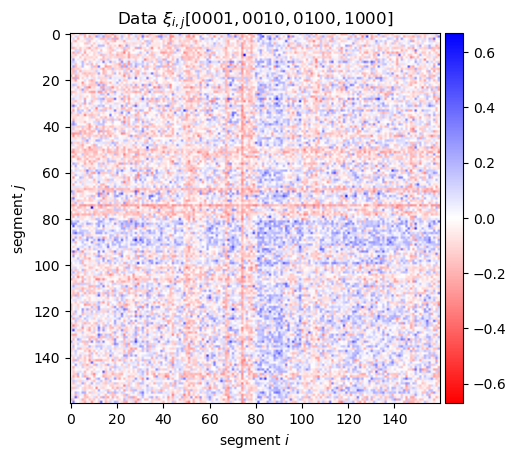

In [28]:
# mutation_profile = [((0,0),(0,1)), ((0,0),(1,0)), ((0,1),(0,0)), ((1,0),(0,0))]
mutation_profile = [((1,),(1,))]

xi_data, _ = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq, 
    segment_size=SEGMENT_SIZE,
    profile_groups=mutation_profile,
)

ax = plot_data_2d(xi_data,);
ax.set_title(f"Data $\\xi_{{i,j}}[0001,0010,0100,1000]$");

In [29]:
N_BOOT = 100

xis_boot = np.zeros([N_BOOT, *xi_data.shape])

for i in tqdm.trange(N_BOOT):
    boot_seqs, boot_expression = generate_bootstrapped_data(
        seqs, expression, wt_seq, rng, 
    )

    xi, _ = compute_expression_shift_by_pairwise_mutation(
        boot_seqs, boot_expression, wt_seq, 
        segment_size=SEGMENT_SIZE,
        profile_groups=mutation_profile,
    )
    xis_boot[i] = xi


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/addisonhowe/Documents/Projects/promoter-dissection/promdis/core.py:446: RuntimeWarning: invalid value encountered in divide
  mean_expression = total_expression / counts


In [30]:
# Compute bootstrapped confidence intervals

xi_boot_ci_lower = np.percentile(xis_boot, 100*ALPHA/2, axis=0)
xi_boot_ci_upper = np.percentile(xis_boot, 100*(1-ALPHA/2), axis=0)

xi_boot_median = np.percentile(xis_boot, 50, axis=0)

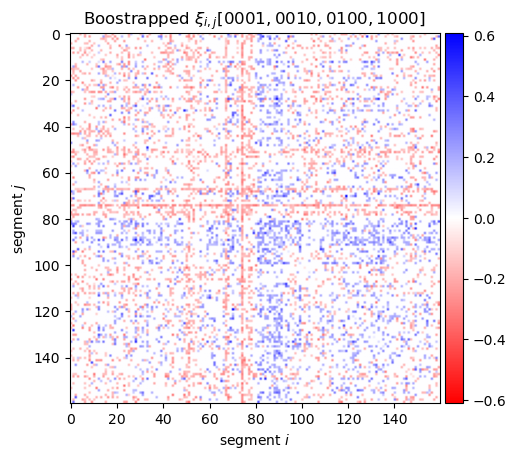

In [31]:

conf_screen = xi_boot_ci_lower * xi_boot_ci_upper > 0

ax = plot_data_2d(
    np.where(conf_screen, xi_boot_median, 0.),
)

ax.set_title(f"Boostrapped $\\xi_{{i,j}}[0001,0010,0100,1000]$");

plt.savefig(f"{OUTDIR}/bootstrapped_xi_2d.pdf")

## Null models

How does this picture compare to a null model?
The alternative hypothesis is that mutations at particular positions impact gene expression, resulting in an average expression value across those mutated sequences that differs from the average over the wildtype sequences.
The null hypothesis is that mutations at a position do not induce a change in gene expression, and that observed differences are simply due to random chance. 
To this end, we can construct a null dataset in which we sample from the empirical distribution of sequences, and associate to each sampled sequence an expression value that is similarly drawn from the empirical distribution of expression values.

In [13]:
def generate_null_data_1d(
        seqs, expression, wt_seq, 
        rng=None, 
        seed=None,
):
    """Generate a null empirical sample.
    
    TODO: description and arguments
    """
    if rng is None:
        rng = np.random.default_rng(seed=seed)
    idxs = rng.choice(len(seqs), len(seqs), replace=True)
    null_seqs = seqs[idxs,:]
    null_expression = rng.permutation(expression)
    return null_seqs, null_expression

In [14]:
N_NULL = 1000

mutation_profile = [(1,0), (0,1)]

xis_null = np.zeros([N_NULL, *xi_data.shape])

for i in tqdm.trange(N_NULL):
    null_seqs, null_expression = generate_null_data_1d(
        seqs, expression, wt_seq, rng, 
    )

    xi, _ = compute_expression_shift_by_mutation(
        null_seqs, null_expression, wt_seq, 
        segment_size=SEGMENT_SIZE,
        profile_groups=mutation_profile,
    )
    xis_null[i] = xi
   

  0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
# Compute null model confidence intervals

xi_null_ci_lower = np.percentile(xis_null, 100*ALPHA/2, axis=0)
xi_null_ci_upper = np.percentile(xis_null, 100*(1-ALPHA/2), axis=0)

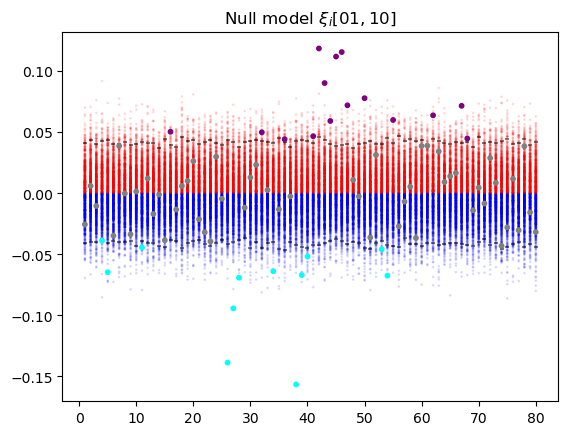

In [16]:
fig, ax = plt.subplots(1, 1)

xs = np.arange(1, len(xi_data) + 1)

for i in range(N_NULL):
    xi = xis_null[i]
    colors = ['b' if v < 0 else 'r' for v in xi]
    ax.scatter(xs, xi, color=colors, s=1, alpha=0.1)

ax.scatter(xs, xi_null_ci_lower, color='k', alpha=0.5, s=5, marker='_')
ax.scatter(xs, xi_null_ci_upper, color='k', alpha=0.5, s=5, marker='_')

colors = []
for i in range(len(xi_data)):
    v = xi_data[i]
    if xi_null_ci_lower[i] < v and v < xi_null_ci_upper[i]:
        colors.append('grey')
    else:
        colors.append('cyan' if v < 0 else 'purple')

ax.scatter(xs, xi_data, color=colors, alpha=1, s=10)

ax.set_title("Null model $\\xi_i[01,10]$");

plt.savefig(f"{OUTDIR}/null_model_xi_1d.pdf")

Now, what if we instead pose the alternative hypothesis that while mutations to a given position may induce some change in expression, pairwise mutations do not have an effect?
Now, in order to generate data corresponding to the null hypothesis, we should respect the fact that mutations to a single segment may change expression, and cannot simply draw expression values from the empirical dataset to assign to each drawn sequence.
Additional care must be taken.

Let us quickly remind ourselves what the pairwise mutation data looks like.
We specify a set of paired mutation profiles, and for every pair of segments $\sigma_i$, $\sigma_j$, we count and find the total expression across all sequences $s\in S$ with $(\Delta(\sigma_i(s)),\,\Delta(\sigma_j(s)))$ matching any of the paired mutation profiles.
We then compute the average expression level, and evaluate the difference between this mean expression level and the wildtype mean expression level.

The difficulty in constructing a null dataset is formulating the problem across multiple segments at once.
For example, if we consider instead the mutation status of a single segment, it is straightforward to draw a random sample of sequences from the empirical dataset, and then for each assign, based on the mutation status at the segment of interest, an expression value drawn either from the pool of empirical expression values obtained from sequences who have a mutation at that segment, or from the pool of expression values obtained from sequences that are of the wildtype at that segment.
In this way, we preserve the possible relation between expression and mutation at the single segment, while removing pairwise interaction of mutations made to two segments.

However, such a construction is specific to a *single* segment, as expression values are partitioned into two mutually exclusive sets based on the mutation profile of the corresponding sequence *at that segment*.

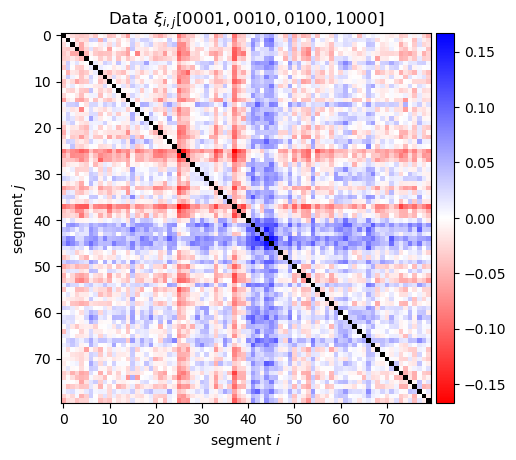

In [18]:
mutation_profile = [((0,0),(0,1)), ((0,0),(1,0)), ((0,1),(0,0)), ((1,0),(0,0))]
xi_data, _ = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq, 
    segment_size=SEGMENT_SIZE,
    profile_groups=mutation_profile,
)

ax = plot_data_2d(xi_data);
ax.set_title(f"Data $\\xi_{{i,j}}[0001,0010,0100,1000]$");

The function below generates a null dataset as described above, that is specific to a particular segment.

In [19]:
def generate_pairwise_null_data_at_segment(
        segment_idx,
        seqs, expression, wt_seq,
        segments,
        mutation_profiles,
        rng=None, 
        seed=None,
):
    """Generate a null empirical sample for the ith position.
    
    TODO: description and arguments
    """
    if rng is None:
        rng = np.random.default_rng(seed=seed)
    
    # Examine segments at position `segment_idx`
    segs_of_interest = segments[:, segment_idx, :]

    # Screen for those that match one of the given mutation profiles
    screen = np.zeros(len(seqs), dtype=bool)
    for profile in mutation_profiles:
        screen = screen | np.all(segs_of_interest == profile, axis=1)
    in_screen_seqs = seqs[screen]
    in_screen_expression = expression[screen]
    out_screen_seqs = seqs[~screen]
    out_screen_expression = expression[~screen]
    num_in_screen = len(in_screen_seqs)
    num_out_screen = len(out_screen_seqs)
    # Randomly sample indexes with replacement out of the total number
    idxs = rng.choice(len(seqs), len(seqs), replace=True)
    in_idxs = idxs[idxs < num_in_screen]
    out_idxs = idxs[idxs >= num_in_screen] - num_in_screen
    # Obtain the random sequences
    null_seqs = np.concatenate([
        in_screen_seqs[in_idxs], out_screen_seqs[out_idxs]
    ])
    # Sample expression values based on mutation status
    in_expression = rng.choice(in_screen_expression, num_in_screen, 
                               replace=True)
    out_expression = rng.choice(out_screen_expression, num_out_screen, 
                                replace=True)
    null_expression = np.concatenate([
        in_expression, out_expression
    ])
    
    return null_seqs, null_expression

In [41]:

# First, perform a segmentation of the empirical dataset
segidxs = get_segments(seqs, segment_size=SEGMENT_SIZE)
nsegments = len(segidxs)
segments = np.array([seqs[i,segidxs] for i in range(len(seqs))] )

print("Shape of sequences dataset:", seqs.shape)
print("Shape of segmented data:", segments.shape)

null_seqs, null_expression = generate_pairwise_null_data_at_segment(
    0,
    seqs, expression, wt_seq,
    segments,
    mutation_profiles=[(0,1), (1,0)],
    rng=rng
)

null_seqs

Shape of sequences dataset: (2590, 160)
Shape of segmented data: (2590, 80, 2)


array([[0, 1, 2, ..., 1, 2, 2],
       [0, 1, 2, ..., 1, 2, 2],
       [0, 1, 2, ..., 1, 2, 2],
       ...,
       [2, 1, 2, ..., 1, 2, 2],
       [3, 1, 2, ..., 1, 2, 2],
       [3, 1, 2, ..., 1, 2, 2]], shape=(2590, 160), dtype=uint8)

In [ ]:
N_NULL = 100

mutation_profile = [((0,0),(0,1)), ((0,0),(1,0)), ((0,1),(0,0)), ((1,0),(0,0))]

xis_null = np.zeros([nsegments, N_NULL, *xi_data.shape])

for i in tqdm.trange(N_NULL):

    for j in range(nsegments):
        null_seqs, null_expression = generate_pairwise_null_data_at_segment(
            j, seqs, expression, wt_seq, 
            segments, 
            mutation_profiles=[(0,1),(1,0),(1,1)],
            rng=rng, 
        )

        xi, _ = compute_expression_shift_by_pairwise_mutation(
            null_seqs, null_expression, wt_seq, 
            segment_size=SEGMENT_SIZE,
            profile_groups=mutation_profile,
        )
        
        xis_null[j,i,:,:] = xi
   

In [ ]:
print(xis_null.shape)


In [ ]:
# np.save(f"{OUTDIR}/xis_null.npy", xis_null)

In [ ]:
# def generate_null_data(
#         seqs, expression, wt_seq, 
#         alphabet_size=4, 
#         rng=None, 
#         seed=None
# ):
#     """Generate random wildtype mutants."""
#     if rng is None:
#         rng = np.random.default_rng(seed=seed)
#     # Count the number of mutations in the true mutated sequences. 
#     nmuts = count_mutations(seqs, wt_seq)
#     # Start with unmutated copies of the wildtype sequence.
#     null_seqs = np.tile(wt_seq, [len(nmuts), 1])
#     # Construct a matrix with same shape that will add a mutation.
#     mut_screen = np.zeros(seqs.shape, dtype=int)
#     mut_screen[:,0] = nmuts
#     nmut_max = nmuts.max()
#     for i in range(nmut_max - 1):
#         mut_screen[:,i+1] = np.maximum(mut_screen[:,i] - 1, 0)
#         mut_screen[:,i] = mut_screen[:,i] > 0
#     assert np.all(mut_screen.sum(1) == nmuts), "Bad mutation screen."
#     # Randomize each row
#     mut_screen = np.apply_along_axis(rng.permutation, axis=1, arr=mut_screen)
#     assert np.all(mut_screen.sum(1) == nmuts), "Bad mutation screen."
#     add_vals = 1 + rng.choice(alphabet_size - 1, nmuts.sum())
#     mut_screen[mut_screen > 0] = add_vals
#     assert np.all((mut_screen > 0).sum(1) == nmuts), "Bad mutation screen."
#     null_expression = expression.copy()
#     null_seqs = (null_seqs + mut_screen) % alphabet_size
#     return null_seqs, null_expression

In [ ]:
# null_seqs, null_expression = generate_null_data(seqs, expression, wt_seq)

# mu = compute_pairwise_segmented_mean_expression(
#     null_seqs, null_expression, wt_seq, 
#     segment_size=SEGMENT_SIZE,
# )

# fig, ax = plt.subplots(1, 1)

# sc = ax.imshow(mu[0,0])
# divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# fig = ax.figure
# cbar = fig.colorbar(sc, cax=cax)

# ax.set_title("Mean wildtype expression $\\mu_{i, j}^*$")
# ax.set_xlabel(f"segment $i$")
# ax.set_ylabel(f"segment $j$");
